#1. Importing Packages

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns


----

#2. Loading data

In [ ]:
!wget 'https://data.insideairbnb.com/germany/be/berlin/2025-09-23/data/listings.csv.gz'

--2026-06-11 22:32:17--  https://data.insideairbnb.com/germany/be/berlin/2025-09-23/data/listings.csv.gz
Resolving data.insideairbnb.com (data.insideairbnb.com)... 3.170.19.60, 3.170.19.41, 3.170.19.81, ...
Connecting to data.insideairbnb.com (data.insideairbnb.com)|3.170.19.60|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7263842 (6.9M) [application/x-gzip]
Saving to: ‘listings.csv.gz’

listings.csv.gz     100%[===================>]   6.93M  --.-KB/s    in 0.1s    

2026-06-11 22:32:17 (70.8 MB/s) - ‘listings.csv.gz’ saved [7263842/7263842]



In [ ]:
!wget 'https://data.insideairbnb.com/germany/be/berlin/2025-09-23/data/calendar.csv.gz'

--2026-06-11 22:32:21--  https://data.insideairbnb.com/germany/be/berlin/2025-09-23/data/calendar.csv.gz
Resolving data.insideairbnb.com (data.insideairbnb.com)... 3.170.19.60, 3.170.19.41, 3.170.19.81, ...
Connecting to data.insideairbnb.com (data.insideairbnb.com)|3.170.19.60|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12087243 (12M) [application/x-gzip]
Saving to: ‘calendar.csv.gz’

calendar.csv.gz     100%[===================>]  11.53M  39.8MB/s    in 0.3s    

2026-06-11 22:32:21 (39.8 MB/s) - ‘calendar.csv.gz’ saved [12087243/12087243]



In [ ]:
!wget 'https://data.insideairbnb.com/germany/be/berlin/2025-09-23/data/reviews.csv.gz'

--2026-06-11 22:32:23--  https://data.insideairbnb.com/germany/be/berlin/2025-09-23/data/reviews.csv.gz
Resolving data.insideairbnb.com (data.insideairbnb.com)... 3.170.19.60, 3.170.19.41, 3.170.19.81, ...
Connecting to data.insideairbnb.com (data.insideairbnb.com)|3.170.19.60|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 72609019 (69M) [application/x-gzip]
Saving to: ‘reviews.csv.gz’

reviews.csv.gz      100%[===================>]  69.25M  36.3MB/s    in 1.9s    

2026-06-11 22:32:26 (36.3 MB/s) - ‘reviews.csv.gz’ saved [72609019/72609019]



In [ ]:
!wget 'https://data.insideairbnb.com/germany/be/berlin/2025-09-23/visualisations/neighbourhoods.csv'

--2026-06-11 22:32:27--  https://data.insideairbnb.com/germany/be/berlin/2025-09-23/visualisations/neighbourhoods.csv
Resolving data.insideairbnb.com (data.insideairbnb.com)... 3.170.19.60, 3.170.19.41, 3.170.19.81, ...
Connecting to data.insideairbnb.com (data.insideairbnb.com)|3.170.19.60|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4350 (4.2K) [application/csv]
Saving to: ‘neighbourhoods.csv’

neighbourhoods.csv  100%[===================>]   4.25K  --.-KB/s    in 0s      

2026-06-11 22:32:27 (1.34 GB/s) - ‘neighbourhoods.csv’ saved [4350/4350]



In [ ]:
!wget 'https://data.insideairbnb.com/germany/be/berlin/2025-09-23/visualisations/neighbourhoods.geojson'

--2026-06-11 22:32:30--  https://data.insideairbnb.com/germany/be/berlin/2025-09-23/visualisations/neighbourhoods.geojson
Resolving data.insideairbnb.com (data.insideairbnb.com)... 3.170.19.60, 3.170.19.41, 3.170.19.81, ...
Connecting to data.insideairbnb.com (data.insideairbnb.com)|3.170.19.60|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 751619 (734K) [application/octet-stream]
Saving to: ‘neighbourhoods.geojson’

neighbourhoods.geoj 100%[===================>] 734.00K  --.-KB/s    in 0.01s   

2026-06-11 22:32:31 (55.1 MB/s) - ‘neighbourhoods.geojson’ saved [751619/751619]



In [ ]:
listings  = pd.read_csv('listings.csv.gz',  compression='gzip', low_memory=False)
listings.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,3176,https://www.airbnb.com/rooms/3176,20250923202926,2025-09-24,city scrape,Fabulous Flat in great Location,This beautiful first floor apartment is situa...,The neighbourhood is famous for its variety of...,https://a0.muscache.com/pictures/hosting/Hosti...,3718,...,4.70,4.92,4.61,First name and Last name: Nicolas Krotz <br/> ...,f,1,1,0,0,0.76
1,9991,https://www.airbnb.com/rooms/9991,20250923202926,2025-09-24,city scrape,Geourgeous flat - outstanding views,4 bedroom with very large windows and outstand...,Prenzlauer Berg is an amazing neighbourhood wh...,https://a0.muscache.com/pictures/42799131/59c8...,33852,...,5.00,4.86,4.86,03/Z/RA/003410-18,f,1,1,0,0,0.06
2,14325,https://www.airbnb.com/rooms/14325,20250923202926,2025-09-24,city scrape,Studio Apartment in Prenzlauer Berg,The apartment is located on the upper second f...,NaN,https://a0.muscache.com/pictures/508703/24988a...,55531,...,4.85,4.60,4.45,NaN,f,4,4,0,0,0.14
3,17904,https://www.airbnb.com/rooms/17904,20250923202926,2025-09-24,city scrape,Beautiful Kreuzberg studio - 3 months minimum,"- apt is available starting October 1, 2025 (m...","The apartment is located in Kreuzberg, which i...",https://a0.muscache.com/pictures/d9a6f8be-54b9...,68997,...,4.92,4.88,4.65,NaN,f,1,1,0,0,1.57
4,20858,https://www.airbnb.com/rooms/20858,20250923202926,2025-09-24,city scrape,Designer Loft in Berlin Mitte,Bright and sunny condo with two balconies in a...,Fantastic vibe in the middle of the popular Ka...,https://a0.muscache.com/pictures/108232/205b19...,71331,...,4.54,4.91,4.39,03/Z/RA/009767-24,f,1,1,0,0,0.89


In [ ]:
reviews   = pd.read_csv('reviews.csv.gz',   compression='gzip', low_memory=False)
reviews.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,3176,4283,2009-06-20,21475,Milind,"excellent stay, i would highly recommend it. a..."
1,3176,134722,2010-11-07,263467,George,Britta's apartment in Berlin is in a great are...
2,3176,144064,2010-11-24,76726,Patricia,"Fantastic, large place in good location. Only ..."
3,3176,156702,2010-12-21,291657,Benedetta,L'appartamento di Britta è molto largo carino ...
4,3176,165048,2011-01-04,279789,Aude,We went in Berlin for the new year eve. The ap...


In [ ]:
calendar  = pd.read_csv('calendar.csv.gz',  compression='gzip', low_memory=False)
calendar.head()

,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,1358910,2025-09-24,f,NaN,NaN,3,365
1,1358910,2025-09-25,f,NaN,NaN,3,365
2,1358910,2025-09-26,t,NaN,NaN,3,365
3,1358910,2025-09-27,t,NaN,NaN,3,365
4,1358910,2025-09-28,t,NaN,NaN,3,365


In [ ]:
neighborhood = pd.read_csv('neighbourhoods.csv')
neighborhood.head()

,neighbourhood_group,neighbourhood
0,Charlottenburg-Wilm.,Barstraße
1,Charlottenburg-Wilm.,Charlottenburg Nord
2,Charlottenburg-Wilm.,Düsseldorfer Straße
3,Charlottenburg-Wilm.,Forst Grunewald
4,Charlottenburg-Wilm.,Grunewald


In [ ]:
neighborhood_gdf = gpd.read_file('neighbourhoods.geojson')
neighborhood_gdf.head()

,neighbourhood,neighbourhood_group,geometry
0,Blankenfelde/Niederschönhausen,Pankow,"MULTIPOLYGON (((13.41191 52.61487, 13.41183 52..."
1,Helmholtzplatz,Pankow,"MULTIPOLYGON (((13.41405 52.54929, 13.41422 52..."
2,Wiesbadener Straße,Charlottenburg-Wilm.,"MULTIPOLYGON (((13.30748 52.46788, 13.30743 52..."
3,Schmöckwitz/Karolinenhof/Rauchfangswerder,Treptow - Köpenick,"MULTIPOLYGON (((13.70973 52.3963, 13.70926 52...."
4,Müggelheim,Treptow - Köpenick,"MULTIPOLYGON (((13.73762 52.4085, 13.73773 52...."


-----

#3. Data Exploration

##3.1. Listings

In [ ]:
print(listings.shape)
for col in listings.columns:
    print(col+': ',listings[col].dtypes)

(14274, 79)
id:  int64
listing_url:  object
scrape_id:  int64
last_scraped:  object
source:  object
name:  object
description:  object
neighborhood_overview:  object
picture_url:  object
host_id:  int64
host_url:  object
host_name:  object
host_since:  object
host_location:  object
host_about:  object
host_response_time:  object
host_response_rate:  object
host_acceptance_rate:  object
host_is_superhost:  object
host_thumbnail_url:  object
host_picture_url:  object
host_neighbourhood:  object
host_listings_count:  float64
host_total_listings_count:  float64
host_verifications:  object
host_has_profile_pic:  object
host_identity_verified:  object
neighbourhood:  object
neighbourhood_cleansed:  object
neighbourhood_group_cleansed:  object
latitude:  float64
longitude:  float64
property_type:  object
room_type:  object
accommodates:  int64
bathrooms:  float64
bathrooms_text:  object
bedrooms:  float64
beds:  float64
amenities:  object
price:  object
minimum_nights:  int64
maximum_nights: 

In [ ]:
missing = listings.isnull().mean().sort_values(ascending=False) * 100
print(missing[missing > 0].round(1))

calendar_updated               100.0
host_neighbourhood              59.3
neighborhood_overview           54.6
neighbourhood                   54.6
host_about                      47.9
host_response_rate              35.2
host_response_time              35.2
price                           35.1
estimated_revenue_l365d         35.1
beds                            35.0
license                         34.9
bathrooms                       34.6
host_acceptance_rate            31.4
review_scores_value             23.2
review_scores_location          23.2
review_scores_checkin           23.2
review_scores_accuracy          23.2
review_scores_communication     23.2
review_scores_cleanliness       23.2
last_review                     23.2
first_review                    23.2
review_scores_rating            23.2
reviews_per_month               23.2
host_location                   21.3
bedrooms                        14.2
has_availability                 6.6
description                      3.9
h

In [ ]:
print(listings['price'].dtype)
print(listings['price'].head(10))
print(listings['price'].isna().sum())

object
0    $105.00
1    $135.00
2     $75.00
3     $32.00
4    $202.00
5        NaN
6    $152.00
7     $65.00
8    $260.00
9     $70.00
Name: price, dtype: object
5010


In [ ]:
listings.describe().T


,count,mean,std,min,25%,50%,75%,max
id,14274.0,5.216123e+17,5.756023e+17,3.176000e+03,2.152686e+07,5.203228e+07,1.096245e+18,1.516055e+18
scrape_id,14274.0,2.025092e+13,6.054900e+00,2.025092e+13,2.025092e+13,2.025092e+13,2.025092e+13,2.025092e+13
host_id,14274.0,1.916958e+08,2.097931e+08,1.581000e+03,1.767847e+07,8.970318e+07,3.622977e+08,7.192701e+08
host_listings_count,14260.0,2.574797e+01,1.066503e+02,1.000000e+00,1.000000e+00,1.000000e+00,5.000000e+00,1.359000e+03
host_total_listings_count,14260.0,2.971837e+01,1.261458e+02,1.000000e+00,1.000000e+00,2.000000e+00,7.000000e+00,2.112000e+03
latitude,14274.0,5.250892e+01,3.382449e-02,5.234172e+01,5.249012e+01,5.250925e+01,5.253175e+01,5.265611e+01
longitude,14274.0,1.340231e+01,6.813727e-02,1.311689e+01,1.336206e+01,1.340988e+01,1.343816e+01,1.372139e+01
accommodates,14274.0,3.052963e+00,1.925029e+00,1.000000e+00,2.000000e+00,2.000000e+00,4.000000e+00,1.600000e+01
bathrooms,9330.0,1.147856e+00,4.804331e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.500000e+01
bedrooms,12250.0,1.356898e+00,8.342827e-01,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,1.400000e+01


-----

#4. Data Cleaning

##4.1. Listings

In [ ]:
## Dropping empty and meaningless columns ##
cols_to_drop = [
    'listing_url', 'scrape_id', 'last_scraped', 'source',
    'host_url', 'host_thumbnail_url', 'host_picture_url',
    'neighbourhood',           # 54.6% missing, use neighbourhood_cleansed instead
    'neighborhood_overview',   # 54.6% missing
    'host_neighbourhood',      # 59.3% missing
    'calendar_updated',        # 100% missing
    'license',                 # 34.9% missing, not useful for price
    'minimum_minimum_nights', 'maximum_minimum_nights',
    'minimum_maximum_nights', 'maximum_maximum_nights',
    'minimum_nights_avg_ntm',  'maximum_nights_avg_ntm',  # redundant with minimum_nights
    'neighbourhood_group_cleansed',
    'has_availability',
    'calendar_last_scraped',
]

df = listings.drop(columns=cols_to_drop)
print(df.shape)

(14274, 58)


In [ ]:
## Cleaning Price Col ##
df = df[df['price'].notna()]                                          # drop missing prices
df['price'] = df['price'].str.replace('[$,]', '', regex=True).astype(float)
df = df[df['price'] > 0]                                             # drop zero prices
df['log_price'] = np.log1p(df['price']) ##log transformation, to handle very extreme outliers

print(f"Rows remaining: {len(df)}")
print(df['price'].describe())

Rows remaining: 9264
count     9264.000000
mean       201.240393
std       1656.989769
min          5.000000
25%         70.000000
50%        104.000000
75%        160.000000
max      50000.000000
Name: price, dtype: float64


In [ ]:
## filter out long-term rentals ##
# listings requiring 30+ nights are not similar to usual Airbnb stays
print(df['minimum_nights'].value_counts().head(20))
df = df[df['minimum_nights'] <= 30]
print(f"Rows after filtering minimum_nights: {len(df)}")

minimum_nights
1      2355
2      1707
92     1673
3      1303
4       457
5       326
90      216
30      205
7       200
93      123
6        94
14       60
29       54
28       53
180      51
10       46
15       34
21       25
95       24
100      21
Name: count, dtype: int64
Rows after filtering minimum_nights: 6983


In [ ]:
## Parsing bathroom text ##
## bathrooms is 34.6% missing but bathrooms_text is only 0.1% missing
def parse_bathrooms(text):
    if pd.isna(text):
        return np.nan
    text = text.lower()
    if 'half' in text or 'half-bath' in text:
        return 0.5
    nums = re.findall(r'\d+\.?\d*', text)
    return float(nums[0]) if nums else np.nan

df['bathrooms_parsed'] = df['bathrooms_text'].apply(parse_bathrooms)
df['bathrooms_parsed'] = df['bathrooms_parsed'].fillna(df['bathrooms_parsed'].median())
df.drop(columns=['bathrooms_text', 'bathrooms'], inplace=True)
print(df['bathrooms_parsed'].value_counts())

bathrooms_parsed
1.0     5672
2.0      617
1.5      413
0.0       65
3.0       65
2.5       57
0.5       54
4.0       23
3.5        5
8.5        4
4.5        3
8.0        2
5.0        1
15.0       1
6.0        1
Name: count, dtype: int64


In [ ]:
## impute bedrooms and beds ##
# bedrooms is 14.2% missing and beds is 35% missing
df['bedrooms'] = df.groupby('room_type')['bedrooms'].transform(
    lambda x: x.fillna(x.median())
)
df['beds'] = df.groupby('room_type')['beds'].transform(
    lambda x: x.fillna(x.median())
)

In [ ]:
## fix boolean/percentage columns ##
# convert t/f strings to booleans
for col in ['host_is_superhost', 'host_has_profile_pic',
            'host_identity_verified', 'instant_bookable']:
    df[col] = df[col].map({'t': 1, 'f': 0})
df['host_is_superhost'] = df['host_is_superhost'].fillna(0) #number of missing values was very low

# strip % from rate columns
for col in ['host_response_rate', 'host_acceptance_rate']:
    df[col] = df[col].str.replace('%', '').astype(float)

In [ ]:
## add a has_reviews flag, then impute review scores ##
df['has_reviews'] = (df['number_of_reviews'] > 0).astype(int)

review_cols = [
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value'
]
for col in review_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
## Neighborhood Overview presence can be a feature ##
df['has_neighborhood_overview'] = listings['neighborhood_overview'].notna().astype(int)

## other columns can be cleaned the same way
df['host_location_given'] = df['host_location'].notna().astype(int)
df.drop(columns=['host_location'], inplace=True)

df['has_host_about'] = df['host_about'].notna().astype(int)
df.drop(columns=['host_about'], inplace=True)

In [ ]:
## missing text data ##
df['has_description'] = df['description'].notna().astype(int)
df['description'] = df['description'].fillna('')

In [ ]:
## creating missing value category ##
# can mean inactive hosts which is a signal
df['host_response_time'] = df['host_response_time'].fillna('unknown')
df['host_response_rate'] = df['host_response_rate'].fillna(-1)  # -1 = unknown
df['host_acceptance_rate'] = df['host_acceptance_rate'].fillna(-1)

In [ ]:
## Host effort Score ##
df['host_effort_score'] = (
    df['has_description'].astype(int) +
    df['has_neighborhood_overview'].astype(int) +
    df['has_host_about'].astype(int) +
    (df['host_has_profile_pic'] == 1).astype(int) +
    (df['host_identity_verified'] == 1).astype(int)
)

In [ ]:
## Extracting durations from dates ##
df['days_since_last_review'] = (
    pd.to_datetime('today') - pd.to_datetime(df['last_review'])
).dt.days
df['days_since_last_review'] = df['days_since_last_review'].fillna(9999)  # 9999 = never reviewed

df.drop(columns=['first_review', 'last_review'], inplace=True)
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [ ]:
print(df.shape)
print(df.isnull().sum()[df.isnull().sum() > 0])

(6983, 61)
host_name                    2
host_since                   2
host_listings_count          2
host_total_listings_count    2
host_verifications           2
host_has_profile_pic         2
host_identity_verified       2
dtype: int64


In [ ]:
## only 2 rows with missing values
df = df.dropna(subset=['host_name', 'host_since', 'host_listings_count',
                        'host_total_listings_count', 'host_verifications',
                        'host_has_profile_pic', 'host_identity_verified'])

In [ ]:
print(df.shape)
print(df.isnull().sum()[df.isnull().sum() > 0])

(6981, 61)
Series([], dtype: int64)


In [ ]:
##Saving
df.to_parquet('listings_clean.parquet', index=False)

----

#5. Data Analysis

##5.1. Listings

### price distribution

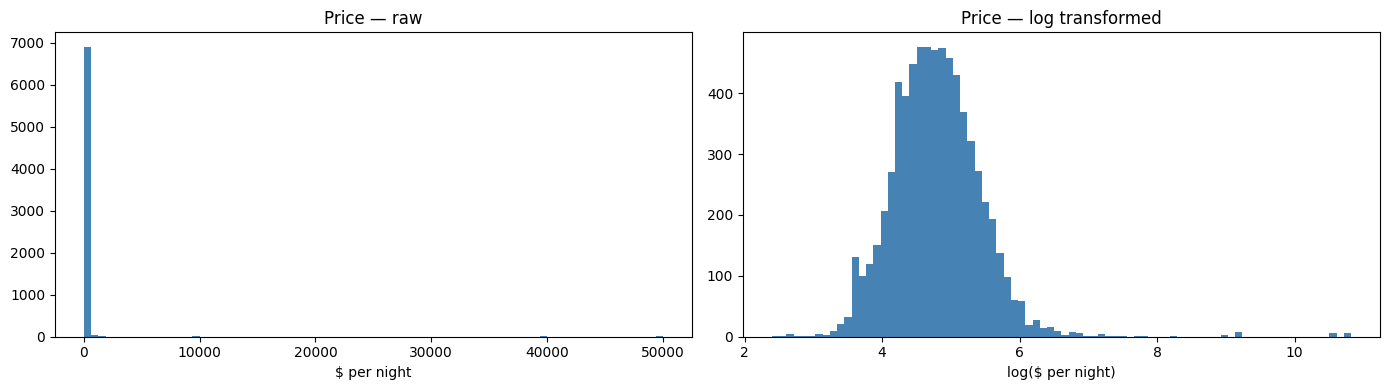

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['price'], bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('Price, raw')
axes[0].set_xlabel('$ per night')

axes[1].hist(df['log_price'], bins=80, color='steelblue', edgecolor='none')
axes[1].set_title('Price, log transformed')
axes[1].set_xlabel('log($ per night)')

plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150)
plt.show()

### Numerical Features

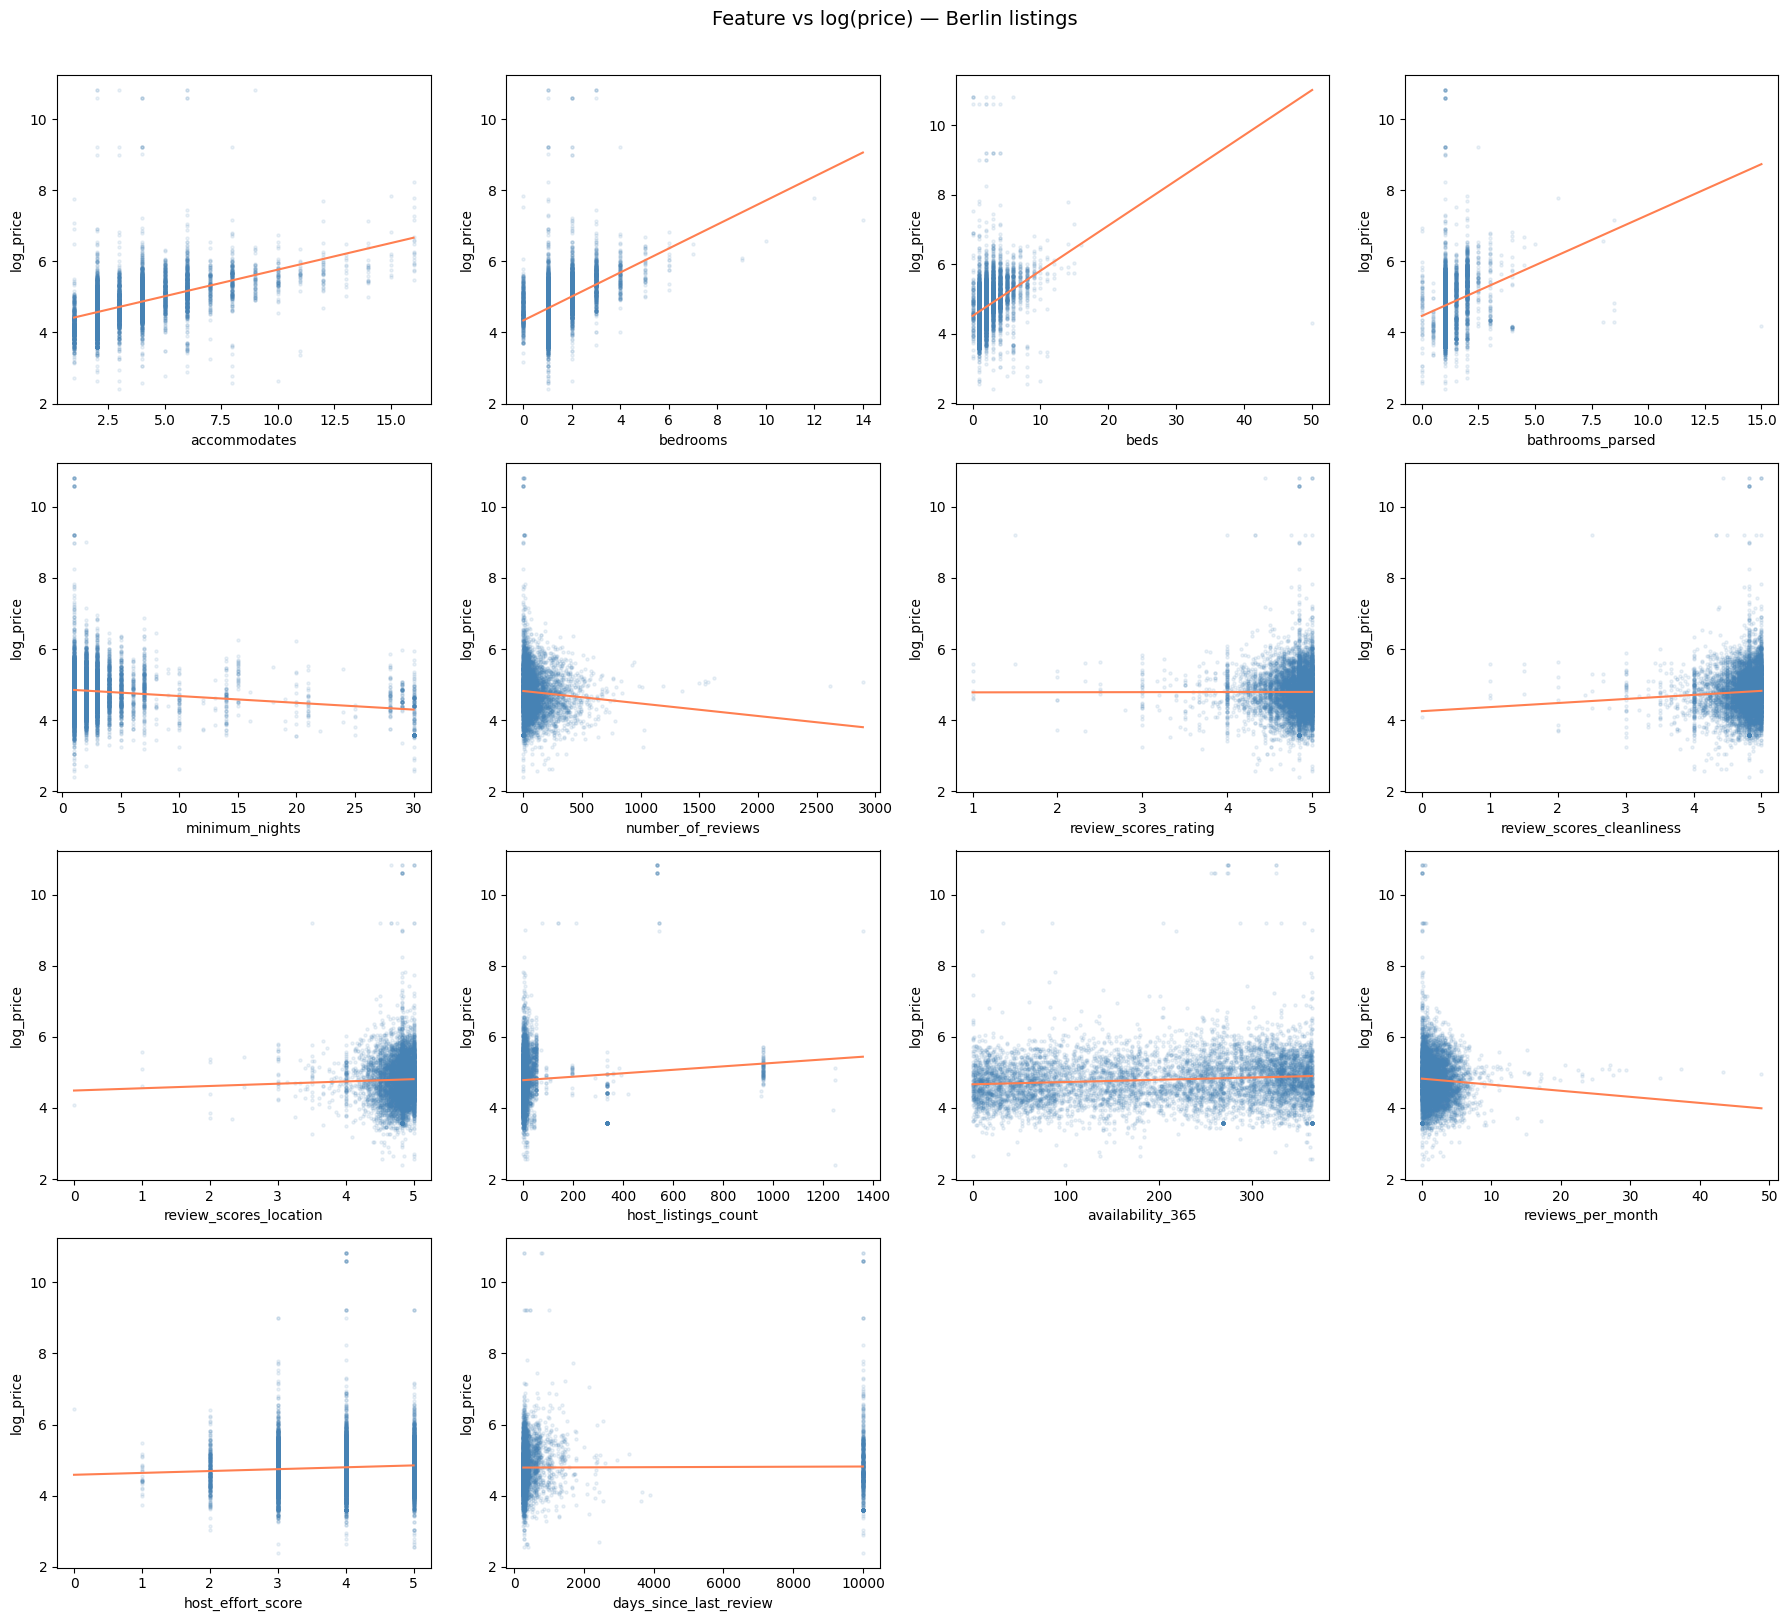

In [ ]:
numeric_features = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms_parsed',
    'minimum_nights', 'number_of_reviews', 'review_scores_rating',
    'review_scores_cleanliness', 'review_scores_location',
    'host_listings_count', 'availability_365',
    'reviews_per_month', 'host_effort_score',
    'days_since_last_review'
]

n = len(numeric_features)
cols = 4
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    axes[i].scatter(
        df[feat], df['log_price'],
        alpha=0.1, s=5, color='steelblue'
    )
    axes[i].set_xlabel(feat, fontsize=10)
    axes[i].set_ylabel('log_price', fontsize=10)

    mask = df[feat].notna()
    z = np.polyfit(df.loc[mask, feat], df.loc[mask, 'log_price'], 1)
    p = np.poly1d(z)
    x_range = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[i].plot(x_range, p(x_range), color='coral', linewidth=1.5)

# hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature vs log(price) — Berlin listings', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('feature_vs_price_grid.png', dpi=150, bbox_inches='tight')
plt.show()

### Boolean data

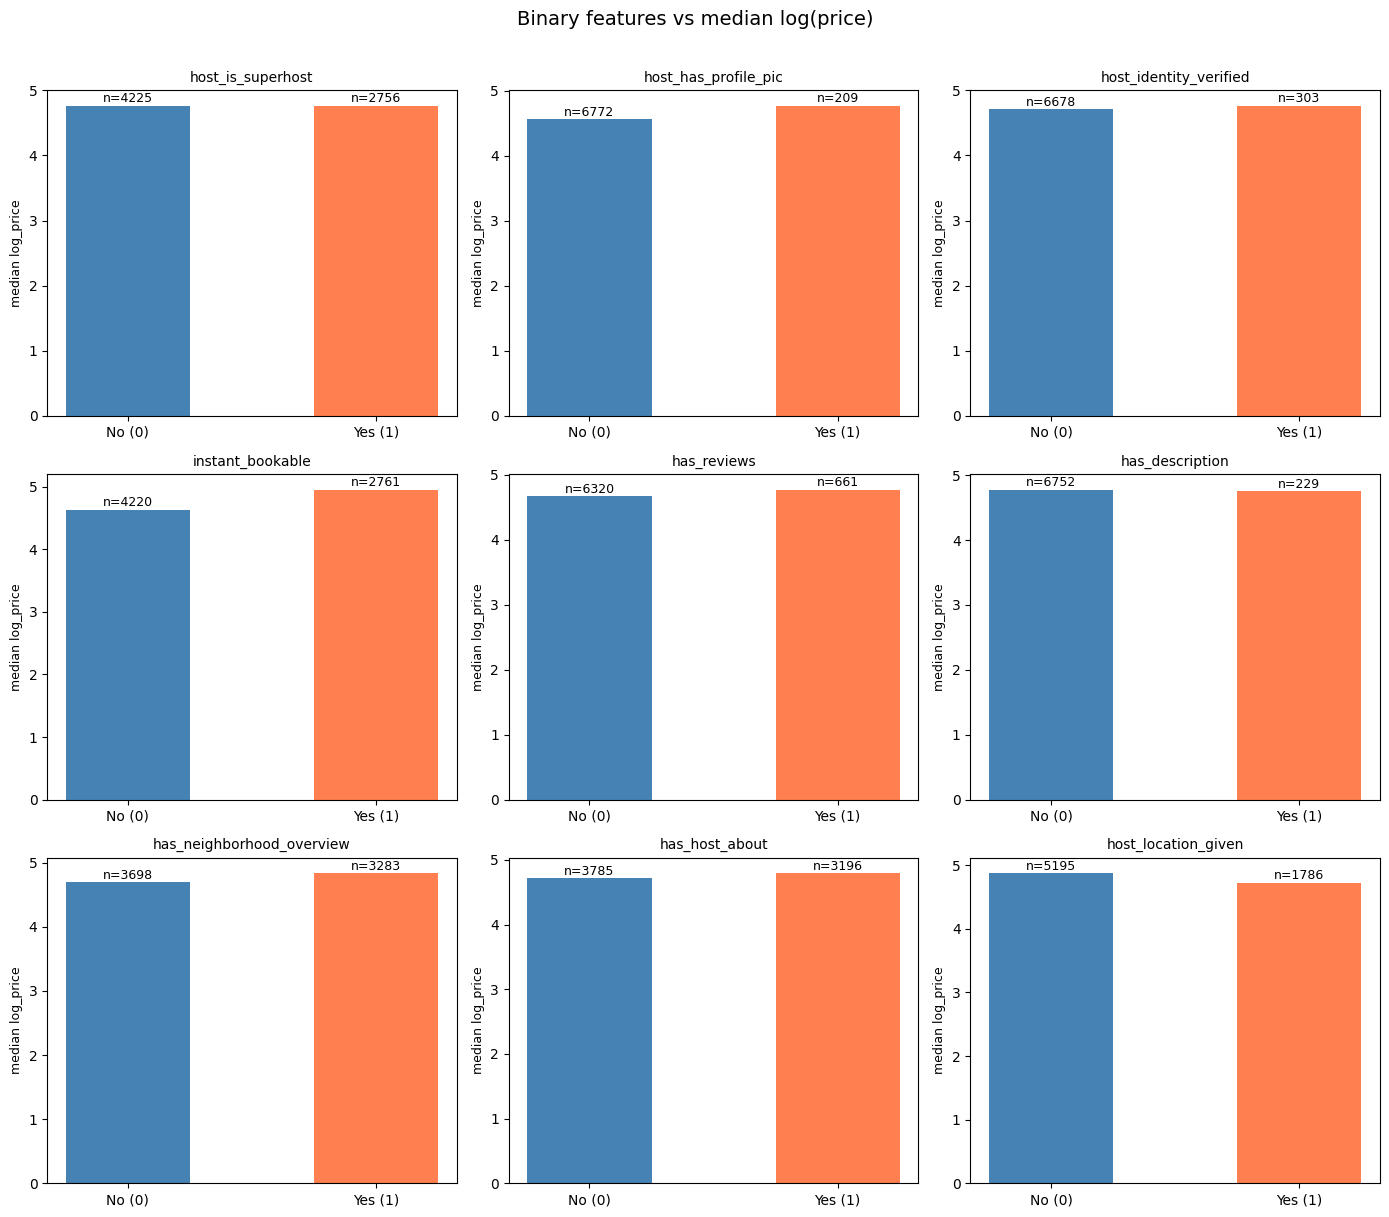

In [ ]:
bool_features = [
    'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified',
    'instant_bookable', 'has_reviews', 'has_description',
    'has_neighborhood_overview', 'has_host_about', 'host_location_given'
]

n = len(bool_features)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 4))
axes = axes.flatten()

for i, feat in enumerate(bool_features):
    medians = df.groupby(feat)['log_price'].median()
    counts = df[feat].value_counts()

    bars = axes[i].bar(
        medians.index.astype(str),
        medians.values,
        color=['steelblue', 'coral'],
        width=0.5
    )

    # add count labels on top of each bar
    for bar, (idx, count) in zip(bars, counts.items()):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'n={count}',
            ha='center', va='bottom', fontsize=9
        )

    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('median log_price', fontsize=9)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No (0)', 'Yes (1)'])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Binary features vs median log(price)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('binary_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

### Categorical Data

/tmp/ipykernel_10688/3553009649.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


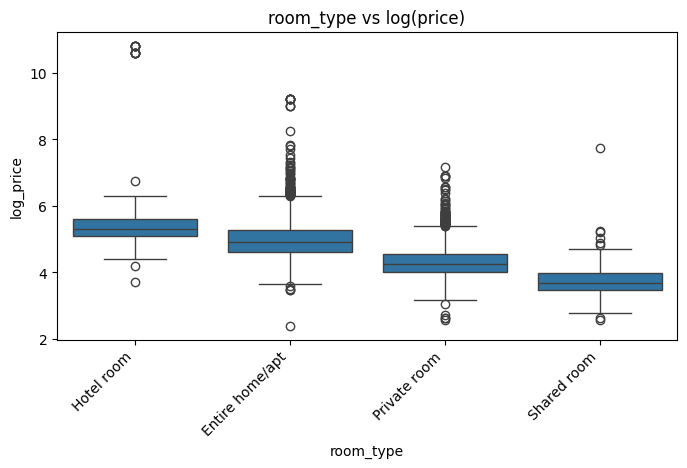

/tmp/ipykernel_10688/3553009649.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


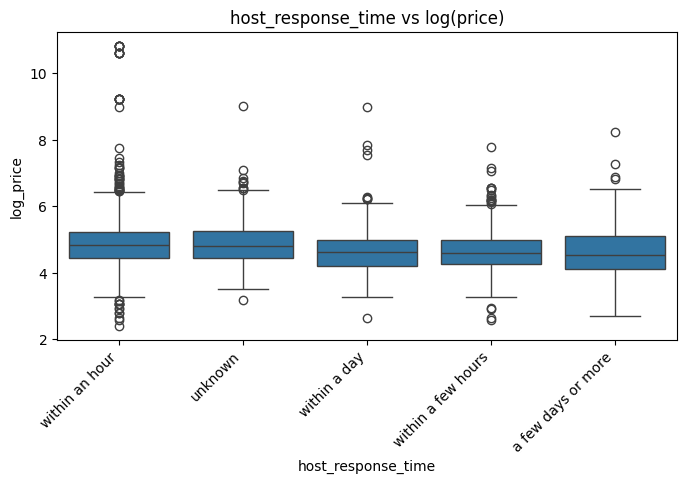

In [ ]:
cat_features = ['room_type', 'host_response_time']

for feat in cat_features:
    fig, ax = plt.subplots(figsize=(8, 4))
    order = df.groupby(feat)['log_price'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=feat, y='log_price', order=order, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_title(f'{feat} vs log(price)')
    plt.savefig(f'{feat}_vs_price.png', dpi=150)
    plt.show()

### price by neighbourhood (top 10)

/tmp/ipykernel_10688/3570259774.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


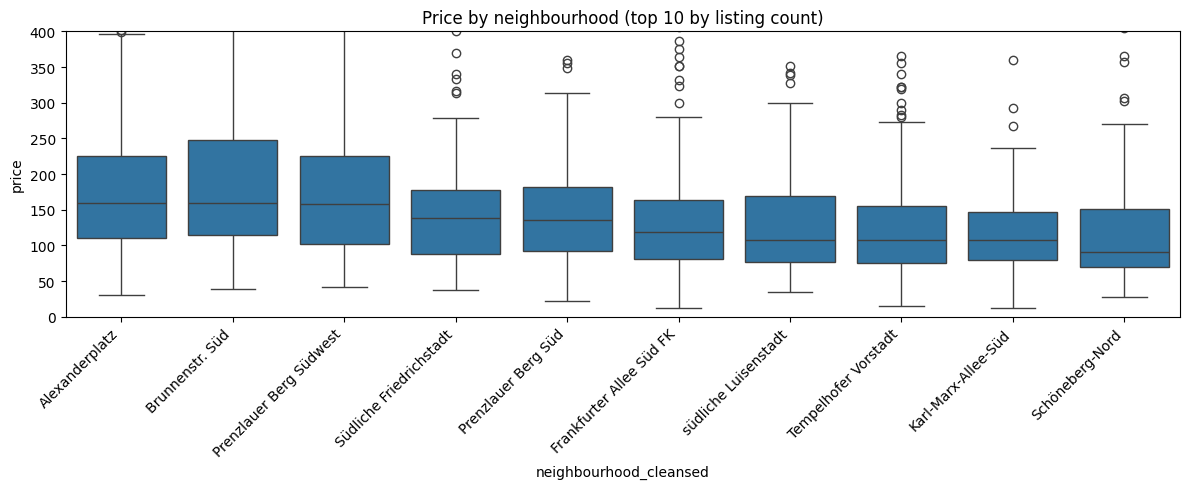

In [ ]:
top_neighbourhoods = df['neighbourhood_cleansed'].value_counts().head(10).index
subset = df[df['neighbourhood_cleansed'].isin(top_neighbourhoods)]

fig, ax = plt.subplots(figsize=(12, 5))
order = subset.groupby('neighbourhood_cleansed')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=subset, x='neighbourhood_cleansed', y='price', order=order, ax=ax)
ax.set_ylim(0, 400)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Price by neighbourhood (top 10 by listing count)')
plt.tight_layout()
plt.savefig('price_by_neighbourhood.png', dpi=150)
plt.show()

### price vs accommodates

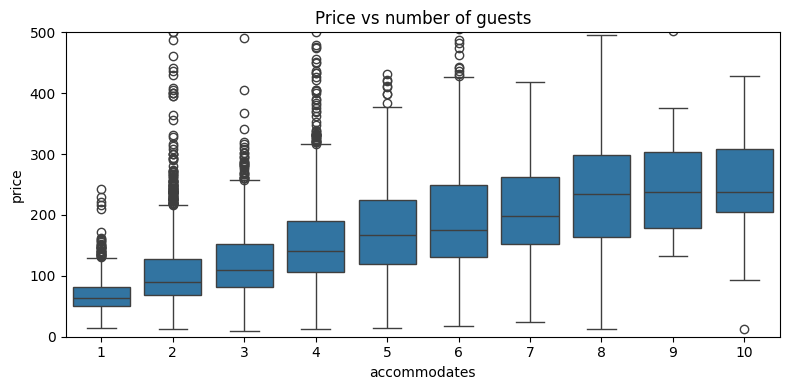

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df[df['accommodates'] <= 10], x='accommodates', y='price', ax=ax)
ax.set_ylim(0, 500)
ax.set_title('Price vs number of guests')
plt.tight_layout()
plt.savefig('price_by_accommodates.png', dpi=150)
plt.show()

### spatial map

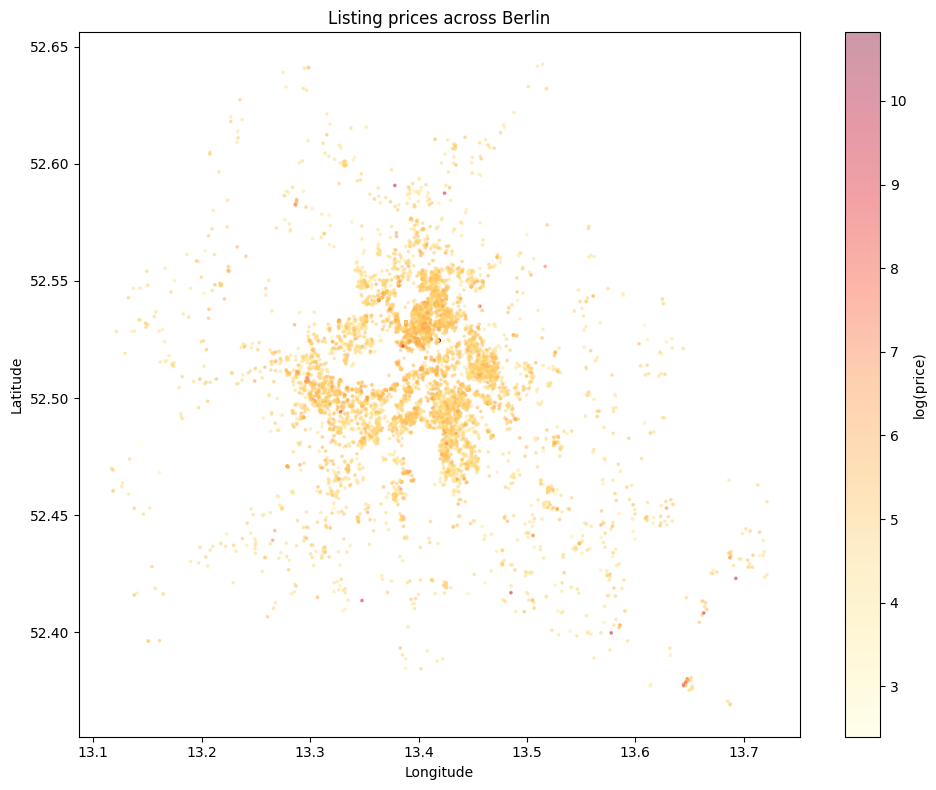

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    df['longitude'], df['latitude'],
    c=df['log_price'], cmap='YlOrRd',
    alpha=0.4, s=3
)
plt.colorbar(scatter, ax=ax, label='log(price)')
ax.set_title('Listing prices across Berlin')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

### Correlation matrix

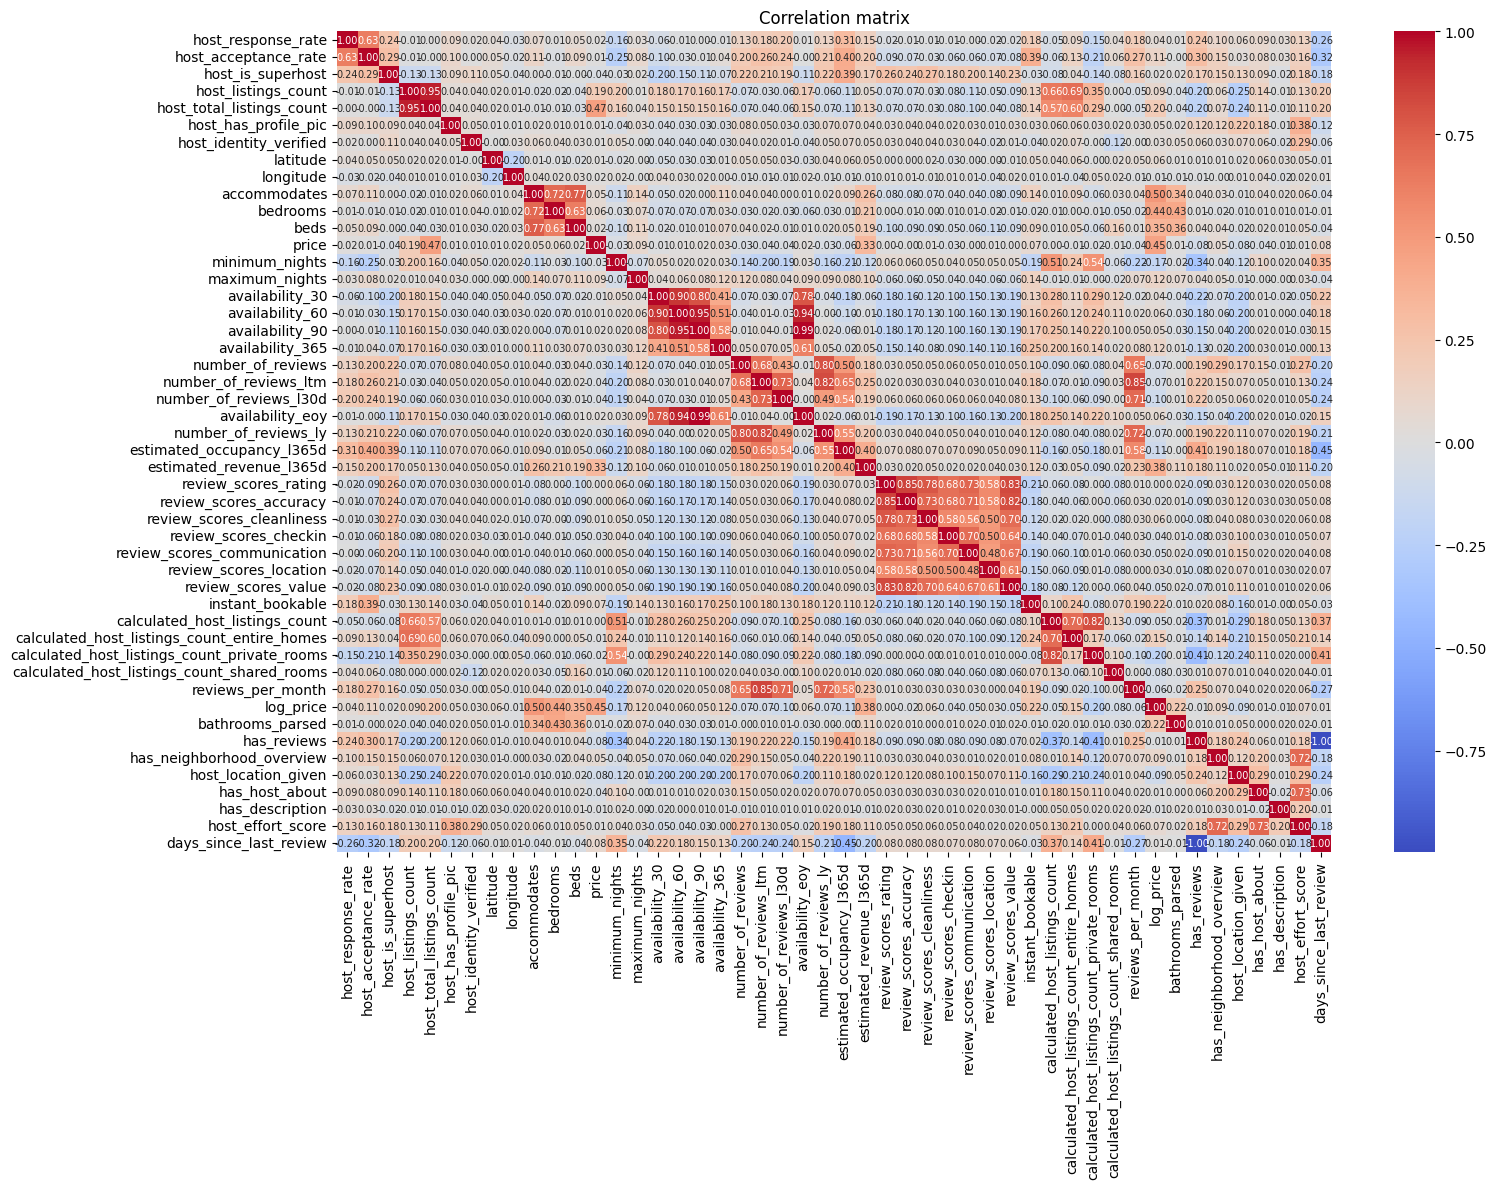

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['id', 'host_id', 'scrape_id']]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    annot_kws={'size': 7},
    ax=ax
)
ax.set_title('Correlation matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()

### Review score distribution

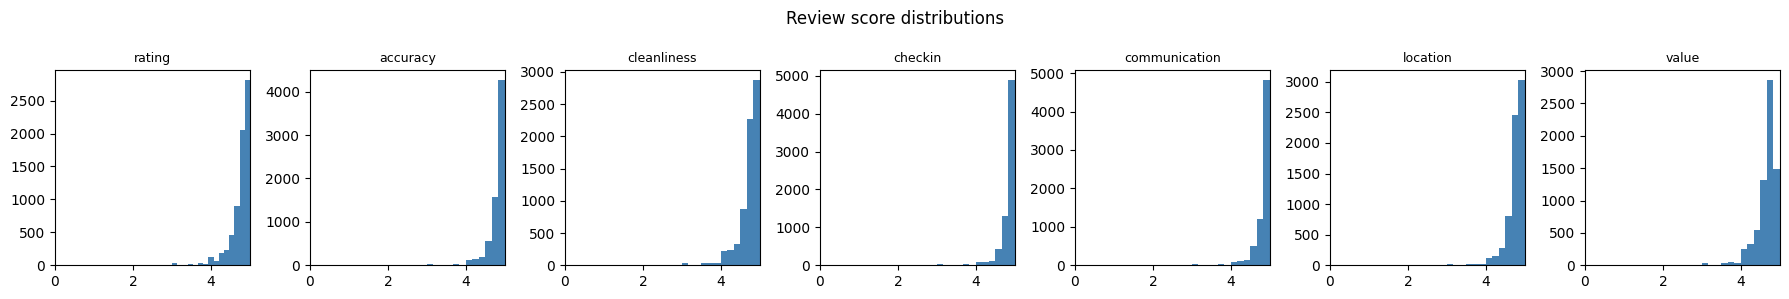

In [ ]:
review_cols = [c for c in df.columns if 'review_scores' in c]

fig, axes = plt.subplots(1, len(review_cols), figsize=(18, 3))
for i, col in enumerate(review_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='none')
    axes[i].set_title(col.replace('review_scores_', ''), fontsize=9)
    axes[i].set_xlim(0, 5)

plt.suptitle('Review score distributions', fontsize=12)
plt.tight_layout()
plt.savefig('review_distributions.png', dpi=150)
plt.show()

In [ ]:
summary = pd.DataFrame({
    'median_price': df.groupby('room_type')['price'].median(),
    'mean_price': df.groupby('room_type')['price'].mean().round(0),
    'count': df.groupby('room_type')['price'].count(),
})
print(summary.sort_values('median_price', ascending=False))


                 median_price  mean_price  count
room_type                                       
Hotel room              197.5      5580.0    100
Entire home/apt         136.0       185.0   4871
Private room             69.0        89.0   1914
Shared room              38.0        72.0     96


-----